# Airport Hubs and Regional Economic Growth  
## Enhanced Dubai–Emirates Case Study Notebook

This notebook is the **enhanced code file** for the airport hubs project. It is designed around the Dubai–Emirates case and accepts the datasets created for this project.

## Data loading and feature engineering

This section:
- loads the input files
- standardizes column names
- creates lagged variables
- adds shock and recovery indicators
- creates interaction terms and dynamic features
- exports a feature-engineered dataset


In [1]:

# ============================================================
# AIRPORT HUBS AND REGIONAL ECONOMIC GROWTH
# Enhanced Dubai–Emirates Case Study Notebook
# ============================================================

# -----------------------------
# 0. OPTIONAL INSTALLS (Colab)
# -----------------------------
# Uncomment if needed:
# !pip -q install pandas numpy matplotlib scikit-learn statsmodels xgboost openpyxl

# -----------------------------
# 1. IMPORTS
# -----------------------------
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False

import statsmodels.api as sm

# -----------------------------
# 2. FOLDERS
# -----------------------------
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR
OUTPUT_DIR = BASE_DIR / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

for d in [OUTPUT_DIR, FIG_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Working directory:", BASE_DIR)
print("Output directory:", OUTPUT_DIR)

# -----------------------------
# 3. LOAD INPUT DATA
# -----------------------------
MASTER_FILE = DATA_DIR / "airport_hub_master_dataset.csv"
DXB_FILE = DATA_DIR / "dxb_passengers.csv"
EMIRATES_FILE = DATA_DIR / "emirates_operating_metrics.csv"
MACRO_FILE = DATA_DIR / "uae_macro_official.csv"
TOURISM_FILE = DATA_DIR / "dubai_tourism.csv"

if MASTER_FILE.exists():
    df = pd.read_csv(MASTER_FILE)
    print("Loaded master dataset:", MASTER_FILE.name)
else:
    print("Master dataset not found. Building from separate files...")
    required_files = [DXB_FILE, EMIRATES_FILE, MACRO_FILE, TOURISM_FILE]
    for f in required_files:
        if not f.exists():
            raise FileNotFoundError(f"Missing required file: {f}")

    dxb = pd.read_csv(DXB_FILE)
    emirates = pd.read_csv(EMIRATES_FILE)
    macro = pd.read_csv(MACRO_FILE)
    tourism = pd.read_csv(TOURISM_FILE)

    df = dxb.merge(emirates, on="year", how="left") \
            .merge(macro, on="year", how="left") \
            .merge(tourism, on="year", how="left")

# -----------------------------
# 4. STANDARDIZE COLUMN NAMES
# -----------------------------
rename_map = {
    "uae_gdp": "uae_gdp",
    "gdp_per_capita": "gdp_per_capita",
    "uae_gdp_per_capita": "gdp_per_capita",
    "gdp_growth": "gdp_growth",
    "uae_gdp_growth": "gdp_growth",
    "tourism_visitors": "tourism_visitors",
    "dubai_tourism_visitors": "tourism_visitors",
    "seat_factor": "seat_factor",
    "passenger_seat_factor_pct": "seat_factor",
    "emirates_passengers": "emirates_passengers",
    "dxb_passengers": "dxb_passengers"
}
df = df.rename(columns={c: rename_map[c] for c in df.columns if c in rename_map})

if "year" not in df.columns:
    raise ValueError("Dataset must contain a 'year' column.")

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df = df.sort_values("year").reset_index(drop=True)

print("\nInitial merged data:")
display(df.head())

# -----------------------------
# 5. REQUIRED CORE COLUMNS CHECK
# -----------------------------
core_cols = ["year", "dxb_passengers", "emirates_passengers", "gdp_growth"]
for col in core_cols:
    if col not in df.columns:
        raise ValueError(f"Required column missing: {col}")

if "tourism_visitors" not in df.columns:
    print("Warning: tourism_visitors not found. Creating blank column.")
    df["tourism_visitors"] = np.nan

if "seat_factor" not in df.columns:
    print("Warning: seat_factor not found. Creating blank column.")
    df["seat_factor"] = np.nan

if "uae_gdp" not in df.columns:
    df["uae_gdp"] = np.nan

if "gdp_per_capita" not in df.columns:
    df["gdp_per_capita"] = np.nan

# -----------------------------
# 6. FEATURE ENGINEERING
# -----------------------------
if "covid_dummy" not in df.columns:
    df["covid_dummy"] = df["year"].isin([2020, 2021]).astype(int)

if "recovery_dummy" not in df.columns:
    df["recovery_dummy"] = (df["year"] >= 2022).astype(int)

df["dxb_passengers_lag1"] = df["dxb_passengers"].shift(1)
df["emirates_passengers_lag1"] = df["emirates_passengers"].shift(1)
df["tourism_visitors_lag1"] = df["tourism_visitors"].shift(1)
df["gdp_growth_lag1"] = df["gdp_growth"].shift(1)

df["dxb_growth_pct"] = df["dxb_passengers"].pct_change() * 100
df["emirates_growth_pct"] = df["emirates_passengers"].pct_change() * 100
df["tourism_growth_pct"] = df["tourism_visitors"].pct_change() * 100
df["uae_gdp_growth_from_level_pct"] = df["uae_gdp"].pct_change() * 100 if df["uae_gdp"].notna().sum() > 1 else np.nan

df["log_dxb_passengers"] = np.log(df["dxb_passengers"].replace(0, np.nan))
df["log_emirates_passengers"] = np.log(df["emirates_passengers"].replace(0, np.nan))
df["log_tourism_visitors"] = np.log(df["tourism_visitors"].replace(0, np.nan))

df["emirates_share_of_dxb"] = df["emirates_passengers"] / df["dxb_passengers"]
df["dxb_x_tourism"] = (df["dxb_passengers"] * df["tourism_visitors"]) / 1e12
df["emirates_x_tourism"] = (df["emirates_passengers"] * df["tourism_visitors"]) / 1e12
df["trend"] = np.arange(len(df))

feature_dataset_path = TABLE_DIR / "feature_engineered_dataset.csv"
df.to_csv(feature_dataset_path, index=False)
print(f"Saved feature-engineered dataset to: {feature_dataset_path}")

display(df)

# -----------------------------
# 7. NOVELTY / CONTRIBUTIONS
# -----------------------------
novelty_text = """
NOVELTY / CONTRIBUTIONS

1. Replaced a simpler airport-to-GDP block with a richer multi-source system:
   DXB traffic + Emirates metrics + UAE macro indicators + Dubai tourism indicators.

2. Added dynamic features:
   - lagged airport traffic
   - lagged airline traffic
   - lagged tourism activity
   - lagged GDP growth

3. Added shock structure:
   - COVID dummy
   - post-COVID recovery dummy

4. Added mechanism variables:
   - tourism visitors
   - interaction terms between airport traffic and tourism

5. Compared multiple techniques:
   - OLS / Linear Regression
   - Ridge
   - Lasso
   - Elastic Net
   - Random Forest
   - Gradient Boosting
   - XGBoost if available

6. Used time-series cross-validation instead of a simple random train/test split.
"""
print(novelty_text)

with open(TABLE_DIR / "novelty_contributions.txt", "w", encoding="utf-8") as f:
    f.write(novelty_text)


Working directory: /content
Output directory: /content/outputs
Loaded master dataset: airport_hub_master_dataset.csv

Initial merged data:


,year,dxb_passengers,emirates_passengers,seat_factor,uae_gdp,gdp_per_capita,gdp_growth,tourism_visitors,covid_dummy,recovery_dummy,dxb_passengers_lag1,emirates_passengers_lag1
0,2019,86396757,NaN,NaN,4.339000e+11,45938.0,1.3,16730000,0,0,NaN,NaN
1,2020,25900000,56200000.0,78.5,3.572000e+11,37991.0,-8.7,5000000,1,0,86396757.0,NaN
2,2021,29110609,6600000.0,44.3,4.224000e+11,44118.0,4.6,7000000,1,0,25900000.0,56200000.0
3,2022,66069981,19600000.0,58.6,5.114000e+11,50759.0,7.5,14360000,0,1,29110609.0,6600000.0
4,2023,87000000,43600000.0,79.5,5.226000e+11,49850.0,4.3,17150000,0,1,66069981.0,19600000.0


Saved feature-engineered dataset to: /content/outputs/tables/feature_engineered_dataset.csv


,year,dxb_passengers,emirates_passengers,seat_factor,uae_gdp,gdp_per_capita,gdp_growth,tourism_visitors,covid_dummy,recovery_dummy,...,emirates_growth_pct,tourism_growth_pct,uae_gdp_growth_from_level_pct,log_dxb_passengers,log_emirates_passengers,log_tourism_visitors,emirates_share_of_dxb,dxb_x_tourism,emirates_x_tourism,trend
0,2019,86396757,NaN,NaN,4.339000e+11,45938.0,1.3,16730000,0,0,...,NaN,NaN,NaN,18.274461,NaN,16.632714,NaN,1445.417745,NaN,0
1,2020,25900000,56200000.0,78.5,3.572000e+11,37991.0,-8.7,5000000,1,0,...,NaN,-70.113568,-17.676884,17.069754,17.844427,15.424948,2.169884,129.500000,281.000,1
2,2021,29110609,6600000.0,44.3,4.224000e+11,44118.0,4.6,7000000,1,0,...,-88.256228,40.000000,18.253080,17.186613,15.702580,15.761421,0.226721,203.774263,46.200,2
3,2022,66069981,19600000.0,58.6,5.114000e+11,50759.0,7.5,14360000,0,1,...,196.969697,105.142857,21.070076,18.006225,16.791040,16.479957,0.296655,948.764927,281.456,3
4,2023,87000000,43600000.0,79.5,5.226000e+11,49850.0,4.3,17150000,0,1,...,122.448980,19.428969,2.190066,18.281419,17.590568,16.657509,0.501149,1492.050000,747.740,4
5,2024,92300000,51900000.0,79.9,5.523000e+11,50273.0,4.0,18720000,0,1,...,19.036697,9.154519,5.683123,18.340555,17.764829,16.745103,0.562297,1727.856000,971.568,5
6,2025,95200000,53700000.0,78.9,NaN,NaN,NaN,19590000,0,1,...,3.468208,4.647436,0.000000,18.371490,17.798924,16.790530,0.564076,1864.968000,1051.983,6



NOVELTY / CONTRIBUTIONS

1. Replaced a simpler airport-to-GDP block with a richer multi-source system:
   DXB traffic + Emirates metrics + UAE macro indicators + Dubai tourism indicators.

2. Added dynamic features:
   - lagged airport traffic
   - lagged airline traffic
   - lagged tourism activity
   - lagged GDP growth

3. Added shock structure:
   - COVID dummy
   - post-COVID recovery dummy

4. Added mechanism variables:
   - tourism visitors
   - interaction terms between airport traffic and tourism

5. Compared multiple techniques:
   - OLS / Linear Regression
   - Ridge
   - Lasso
   - Elastic Net
   - Random Forest
   - Gradient Boosting
   - XGBoost if available

6. Used time-series cross-validation instead of a simple random train/test split.



## Exploratory analysis

This section gives:
- missing-value checks
- descriptive statistics
- correlation matrix
- core trend charts for DXB traffic, tourism, and UAE GDP growth


In [2]:

# -----------------------------
# 8. EDA AND SUMMARY TABLES
# -----------------------------
print("Dataset info:")
print(df.info())

print("\nMissing values:")
display(df.isna().sum().to_frame("missing_count"))

print("\nDescriptive statistics:")
display(df.describe(include="all"))

corr_cols = [
    "dxb_passengers",
    "emirates_passengers",
    "tourism_visitors",
    "seat_factor",
    "gdp_growth",
    "dxb_growth_pct",
    "emirates_growth_pct",
    "tourism_growth_pct",
    "emirates_share_of_dxb"
]
corr_cols = [c for c in corr_cols if c in df.columns]
corr_df = df[corr_cols].corr(numeric_only=True)
corr_df.to_csv(TABLE_DIR / "correlation_matrix.csv")
display(corr_df)


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   year                           7 non-null      int64  
 1   dxb_passengers                 7 non-null      int64  
 2   emirates_passengers            6 non-null      float64
 3   seat_factor                    6 non-null      float64
 4   uae_gdp                        6 non-null      float64
 5   gdp_per_capita                 6 non-null      float64
 6   gdp_growth                     6 non-null      float64
 7   tourism_visitors               7 non-null      int64  
 8   covid_dummy                    7 non-null      int64  
 9   recovery_dummy                 7 non-null      int64  
 10  dxb_passengers_lag1            6 non-null      float64
 11  emirates_passengers_lag1       5 non-null      float64
 12  tourism_visitors_lag1          6 non-nul

,missing_count
year,0
dxb_passengers,0
emirates_passengers,1
seat_factor,1
uae_gdp,1
gdp_per_capita,1
gdp_growth,1
tourism_visitors,0
covid_dummy,0
recovery_dummy,0



Descriptive statistics:


,year,dxb_passengers,emirates_passengers,seat_factor,uae_gdp,gdp_per_capita,gdp_growth,tourism_visitors,covid_dummy,recovery_dummy,...,emirates_growth_pct,tourism_growth_pct,uae_gdp_growth_from_level_pct,log_dxb_passengers,log_emirates_passengers,log_tourism_visitors,emirates_share_of_dxb,dxb_x_tourism,emirates_x_tourism,trend
count,7.000000,7.000000e+00,6.000000e+00,6.000000,6.000000e+00,6.000000,6.000000,7.000000e+00,7.000000,7.000000,...,5.000000,6.000000,6.000000,7.000000,6.000000,7.000000,6.000000,7.000000,6.000000,7.000000
mean,2022.000000,6.885391e+07,3.860000e+07,69.950000,4.666333e+11,46488.166667,2.166667,1.407857e+07,0.285714,0.571429,...,50.733471,18.043369,4.919910,17.932931,17.248728,16.356026,0.720130,1116.047276,563.324500,3.000000
std,2.160247,2.975787e+07,2.061388e+07,15.034327,7.413341e+10,4939.415326,5.676501,5.787750e+06,0.487950,0.534522,...,110.775646,56.745824,14.010399,0.563326,0.853327,0.539049,0.724125,709.290265,416.181135,2.160247
min,2019.000000,2.590000e+07,6.600000e+06,44.300000,3.572000e+11,37991.000000,-8.700000,5.000000e+06,0.000000,0.000000,...,-88.256228,-70.113568,-17.676884,17.069754,15.702580,15.424948,0.226721,129.500000,46.200000,0.000000
25%,2020.500000,4.759030e+07,2.560000e+07,63.575000,4.252750e+11,44573.000000,1.975000,1.068000e+07,0.000000,0.000000,...,3.468208,5.774207,0.547517,17.596419,16.990922,16.120689,0.347779,576.269595,281.114000,1.500000
50%,2022.000000,8.639676e+07,4.775000e+07,78.700000,4.726500e+11,47894.000000,4.150000,1.673000e+07,0.000000,1.000000,...,19.036697,14.291744,3.936595,18.274461,17.677699,16.632714,0.531723,1445.417745,514.598000,3.000000
75%,2023.500000,8.965000e+07,5.325000e+07,79.350000,5.198000e+11,50167.250000,4.525000,1.793500e+07,0.500000,1.000000,...,122.448980,34.857242,15.110590,18.310987,17.790400,16.701306,0.563631,1609.953000,915.611000,4.500000
max,2025.000000,9.520000e+07,5.620000e+07,79.900000,5.523000e+11,50759.000000,7.500000,1.959000e+07,1.000000,1.000000,...,196.969697,105.142857,21.070076,18.371490,17.844427,16.790530,2.169884,1864.968000,1051.983000,6.000000


,dxb_passengers,emirates_passengers,tourism_visitors,seat_factor,gdp_growth,dxb_growth_pct,emirates_growth_pct,tourism_growth_pct,emirates_share_of_dxb
dxb_passengers,1.000000,0.421988,0.993605,0.560448,0.495074,0.328313,0.363155,0.239096,-0.467409
emirates_passengers,0.421988,1.000000,0.346396,0.969399,-0.611095,-0.573088,0.096215,-0.721972,0.586858
tourism_visitors,0.993605,0.346396,1.000000,0.483297,0.585942,0.392865,0.372041,0.317060,-0.536137
seat_factor,0.560448,0.969399,0.483297,1.000000,-0.431656,-0.411547,0.258876,-0.586217,0.455589
gdp_growth,0.495074,-0.611095,0.585942,-0.431656,1.000000,0.855490,0.659733,0.915356,-0.981175
dxb_growth_pct,0.328313,-0.573088,0.392865,-0.411547,0.855490,1.000000,0.814483,0.967652,-0.737763
emirates_growth_pct,0.363155,0.096215,0.372041,0.258876,0.659733,0.814483,1.000000,0.586755,0.047555
tourism_growth_pct,0.239096,-0.721972,0.317060,-0.586217,0.915356,0.967652,0.586755,1.000000,-0.838790
emirates_share_of_dxb,-0.467409,0.586858,-0.536137,0.455589,-0.981175,-0.737763,0.047555,-0.838790,1.000000


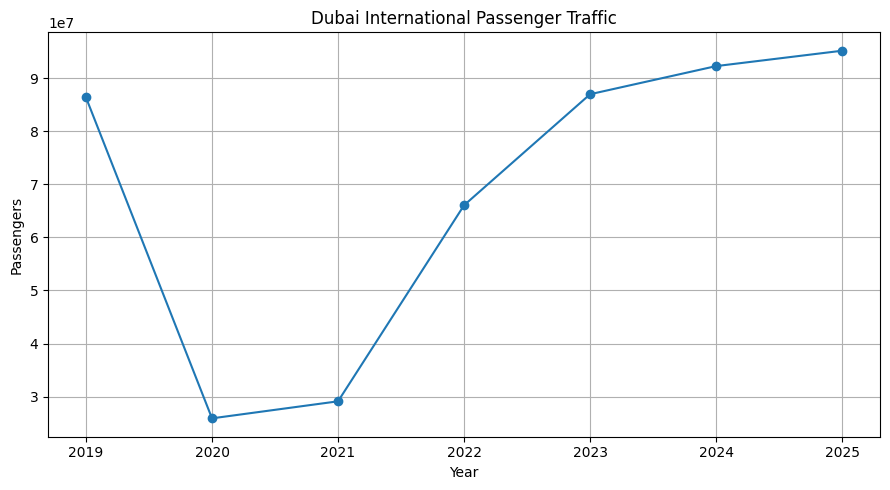

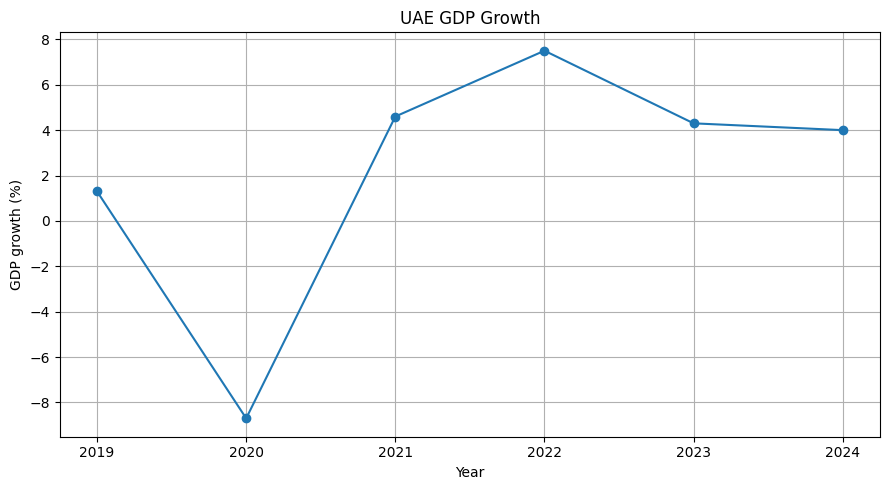

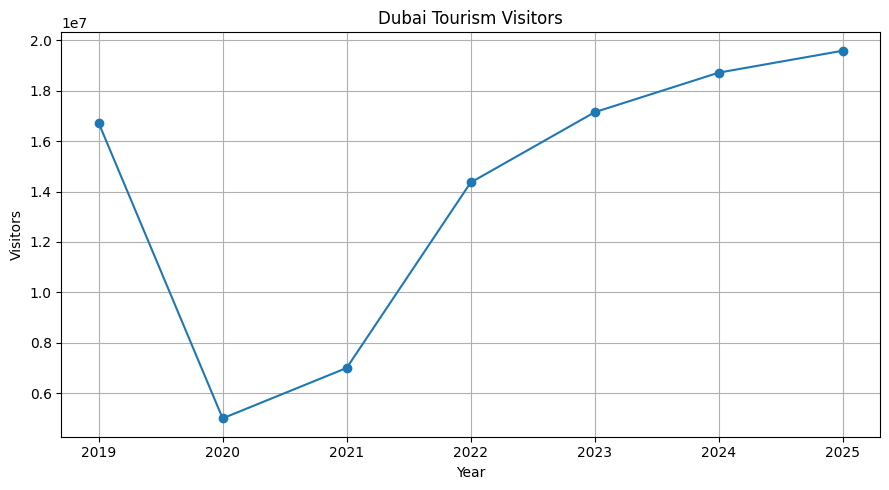

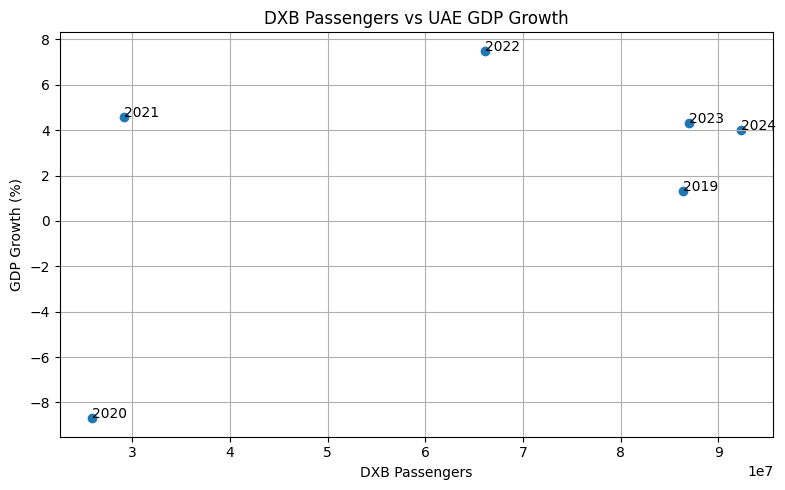

In [3]:

# -----------------------------
# 9. VISUALS
# -----------------------------
plt.figure(figsize=(9, 5))
plt.plot(df["year"], df["dxb_passengers"], marker="o")
plt.title("Dubai International Passenger Traffic")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.grid(True)
plt.tight_layout()
plt.savefig(FIG_DIR / "dxb_passengers_trend.png")
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(df["year"], df["gdp_growth"], marker="o")
plt.title("UAE GDP Growth")
plt.xlabel("Year")
plt.ylabel("GDP growth (%)")
plt.grid(True)
plt.tight_layout()
plt.savefig(FIG_DIR / "uae_gdp_growth_trend.png")
plt.show()

if df["tourism_visitors"].notna().sum() > 0:
    plt.figure(figsize=(9, 5))
    plt.plot(df["year"], df["tourism_visitors"], marker="o")
    plt.title("Dubai Tourism Visitors")
    plt.xlabel("Year")
    plt.ylabel("Visitors")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "tourism_visitors_trend.png")
    plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df["dxb_passengers"], df["gdp_growth"])
for _, row in df.iterrows():
    plt.annotate(int(row["year"]), (row["dxb_passengers"], row["gdp_growth"]))
plt.title("DXB Passengers vs UAE GDP Growth")
plt.xlabel("DXB Passengers")
plt.ylabel("GDP Growth (%)")
plt.grid(True)
plt.tight_layout()
plt.savefig(FIG_DIR / "dxb_vs_gdp_growth_scatter.png")
plt.show()


## Modeling and comparative results

This section:
- defines the modeling dataset
- runs an interpretable **OLS baseline**
- runs a **time-series cross-validated** comparison across multiple techniques
- saves a ranked comparison table for the paper


In [4]:

# -----------------------------
# 10. MODELING DATASET
# -----------------------------
candidate_features = [
    "dxb_passengers",
    "emirates_passengers",
    "tourism_visitors",
    "seat_factor",
    "covid_dummy",
    "recovery_dummy",
    "dxb_passengers_lag1",
    "emirates_passengers_lag1",
    "tourism_visitors_lag1",
    "gdp_growth_lag1",
    "dxb_growth_pct",
    "emirates_growth_pct",
    "tourism_growth_pct",
    "emirates_share_of_dxb",
    "dxb_x_tourism",
    "emirates_x_tourism",
    "trend"
]
candidate_features = [c for c in candidate_features if c in df.columns]

target = "gdp_growth"

model_df = df[["year", target] + candidate_features].copy()
model_df = model_df.dropna(subset=[target]).reset_index(drop=True)

X_full = model_df[candidate_features].copy()
y_full = model_df[target].copy()
X_full = X_full.replace([np.inf, -np.inf], np.nan)

for col in X_full.columns:
    if X_full[col].isna().any():
        X_full[col] = X_full[col].fillna(X_full[col].median())

valid_idx = X_full.dropna().index.intersection(y_full.dropna().index)
X = X_full.loc[valid_idx].reset_index(drop=True)
y = y_full.loc[valid_idx].reset_index(drop=True)
years_used = model_df.loc[valid_idx, "year"].reset_index(drop=True)

print("Modeling years used:", years_used.tolist())
print("Features used:", X.columns.tolist())
display(X)
display(y.to_frame("gdp_growth"))

# -----------------------------
# 11. OLS BASELINE
# -----------------------------
X_ols = sm.add_constant(X)
ols_model = sm.OLS(y, X_ols).fit()

with open(TABLE_DIR / "ols_summary.txt", "w", encoding="utf-8") as f:
    f.write(ols_model.summary().as_text())

print(ols_model.summary())

# -----------------------------
# 12. TIME-SERIES CROSS-VALIDATED MODEL COMPARISON
# -----------------------------
n_obs = len(X)
if n_obs < 5:
    raise ValueError("Not enough observations for modeling after feature engineering.")

n_splits = min(3, n_obs - 2)
tscv = TimeSeriesSplit(n_splits=n_splits)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.05),
    "Elastic Net": ElasticNet(alpha=0.05, l1_ratio=0.5, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, max_depth=3),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42, n_estimators=100, max_depth=2)
}

if HAS_XGB:
    models["XGBoost"] = XGBRegressor(
        random_state=42,
        n_estimators=100,
        max_depth=2,
        learning_rate=0.05,
        objective="reg:squarederror"
    )

results = []

for model_name, model in models.items():
    fold_mae, fold_rmse, fold_r2 = [], [], []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        try:
            r2 = r2_score(y_test, preds)
        except Exception:
            r2 = np.nan

        fold_mae.append(mae)
        fold_rmse.append(rmse)
        fold_r2.append(r2)

        fold_df = pd.DataFrame({
            "year": years_used.iloc[test_idx].values,
            "actual": y_test.values,
            "predicted": preds
        })
        fold_df.to_csv(TABLE_DIR / f"{model_name.lower().replace(' ', '_')}_fold_{fold}_predictions.csv", index=False)

    results.append({
        "Model": model_name,
        "Mean_MAE": np.mean(fold_mae),
        "Mean_RMSE": np.mean(fold_rmse),
        "Mean_R2": np.nanmean(fold_r2)
    })

results_df = pd.DataFrame(results).sort_values("Mean_RMSE").reset_index(drop=True)
results_df.to_csv(TABLE_DIR / "model_comparison_results.csv", index=False)

print("Model comparison results:")
display(results_df)


Modeling years used: [2019, 2020, 2021, 2022, 2023, 2024]
Features used: ['dxb_passengers', 'emirates_passengers', 'tourism_visitors', 'seat_factor', 'covid_dummy', 'recovery_dummy', 'dxb_passengers_lag1', 'emirates_passengers_lag1', 'tourism_visitors_lag1', 'gdp_growth_lag1', 'dxb_growth_pct', 'emirates_growth_pct', 'tourism_growth_pct', 'emirates_share_of_dxb', 'dxb_x_tourism', 'emirates_x_tourism', 'trend']


,dxb_passengers,emirates_passengers,tourism_visitors,seat_factor,covid_dummy,recovery_dummy,dxb_passengers_lag1,emirates_passengers_lag1,tourism_visitors_lag1,gdp_growth_lag1,dxb_growth_pct,emirates_growth_pct,tourism_growth_pct,emirates_share_of_dxb,dxb_x_tourism,emirates_x_tourism,trend
0,86396757,43600000.0,16730000,78.5,0,0,66069981.0,31600000.0,14360000.0,4.3,12.396174,70.742838,19.428969,0.501149,1445.417745,281.456,0
1,25900000,56200000.0,5000000,78.5,1,0,86396757.0,31600000.0,16730000.0,1.3,-70.022023,70.742838,-70.113568,2.169884,129.500000,281.000,1
2,29110609,6600000.0,7000000,44.3,1,0,25900000.0,56200000.0,5000000.0,-8.7,12.396174,-88.256228,40.000000,0.226721,203.774263,46.200,2
3,66069981,19600000.0,14360000,58.6,0,1,29110609.0,6600000.0,7000000.0,4.6,126.961865,196.969697,105.142857,0.296655,948.764927,281.456,3
4,87000000,43600000.0,17150000,79.5,0,1,66069981.0,19600000.0,14360000.0,7.5,31.678561,122.448980,19.428969,0.501149,1492.050000,747.740,4
5,92300000,51900000.0,18720000,79.9,0,1,87000000.0,43600000.0,17150000.0,4.3,6.091954,19.036697,9.154519,0.562297,1727.856000,971.568,5


,gdp_growth
0,1.3
1,-8.7
2,4.6
3,7.5
4,4.3
5,4.0


                            OLS Regression Results                            
Dep. Variable:             gdp_growth   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Sun, 12 Apr 2026   Prob (F-statistic):                nan
Time:                        23:53:53   Log-Likelihood:                 170.97
No. Observations:                   6   AIC:                            -329.9
Df Residuals:                       0   BIC:                            -331.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


Model comparison results:


,Model,Mean_MAE,Mean_RMSE,Mean_R2
0,XGBoost,1.544111,1.544111,NaN
1,Elastic Net,1.795469,1.795469,NaN
2,Lasso,1.795653,1.795653,NaN
3,Ridge,1.888530,1.888530,NaN
4,Linear Regression,1.888530,1.888530,NaN
5,Gradient Boosting,3.808703,3.808703,NaN
6,Random Forest,3.845333,3.845333,NaN


In [5]:

# -----------------------------
# 13. BEST MODEL + FEATURE EFFECTS
# -----------------------------
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
best_model.fit(X, y)
full_preds = best_model.predict(X)

fitted_df = pd.DataFrame({
    "year": years_used,
    "actual_gdp_growth": y,
    "predicted_gdp_growth": full_preds,
    "residual": y - full_preds
})
fitted_df.to_csv(TABLE_DIR / "best_model_fitted_values.csv", index=False)

print(f"Best model: {best_model_name}")
display(fitted_df)

importance_df = None

if best_model_name in ["Random Forest", "Gradient Boosting", "XGBoost"]:
    if hasattr(best_model, "feature_importances_"):
        importance_df = pd.DataFrame({
            "Feature": X.columns,
            "Importance": best_model.feature_importances_
        }).sort_values("Importance", ascending=False)

elif best_model_name in ["Linear Regression", "Ridge", "Lasso", "Elastic Net"]:
    if hasattr(best_model, "coef_"):
        importance_df = pd.DataFrame({
            "Feature": X.columns,
            "Coefficient": best_model.coef_
        }).sort_values("Coefficient", key=lambda s: np.abs(s), ascending=False)

if importance_df is not None:
    importance_df.to_csv(TABLE_DIR / "best_model_feature_importance.csv", index=False)
    display(importance_df)


Best model: XGBoost


,year,actual_gdp_growth,predicted_gdp_growth,residual
0,2019,1.3,1.447018,-0.147018
1,2020,-8.7,-7.835912,-0.864088
2,2021,4.6,4.507031,0.092969
3,2022,7.5,6.992274,0.507726
4,2023,4.3,4.215607,0.084393
5,2024,4.0,4.125912,-0.125912


,Feature,Importance
0,dxb_passengers,0.703067
16,trend,0.254474
7,emirates_passengers_lag1,0.042458
3,seat_factor,0.000000
1,emirates_passengers,0.000000
4,covid_dummy,0.000000
5,recovery_dummy,0.000000
6,dxb_passengers_lag1,0.000000
2,tourism_visitors,0.000000
8,tourism_visitors_lag1,0.000000


## Outputs for the paper

This section exports:
- model comparison table
- OLS summary
- best-model fitted values
- feature effects / importance
- paper-ready summary tables
- visuals for the write-up


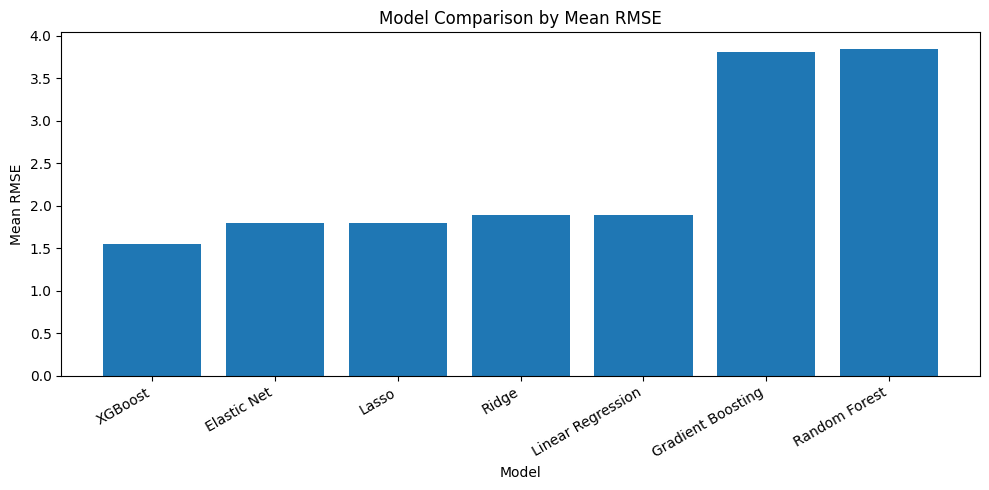

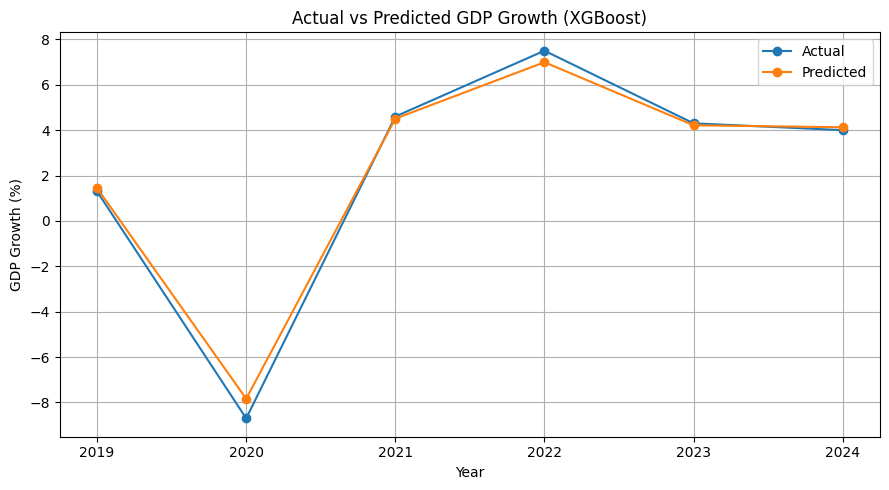

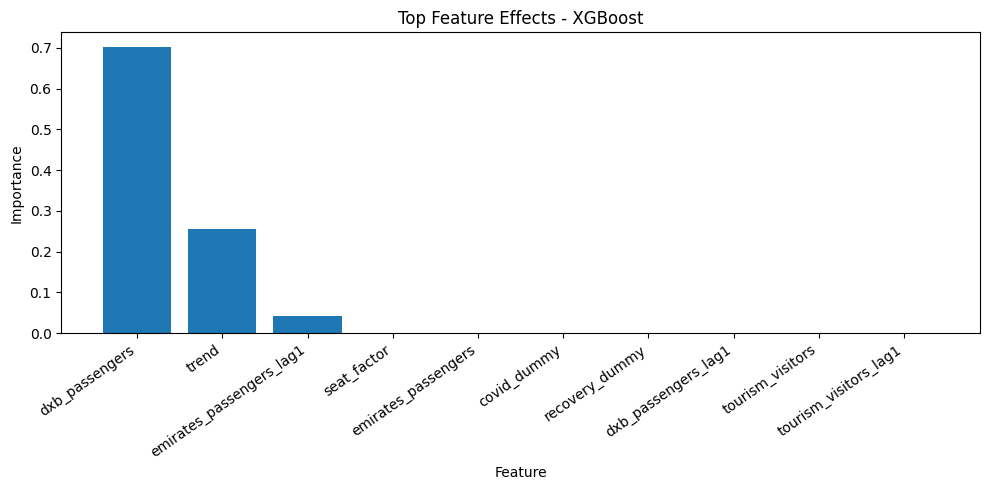

,Rank_by_RMSE,Model,Mean_MAE,Mean_RMSE,Mean_R2
0,1,XGBoost,1.544111,1.544111,NaN
1,2,Elastic Net,1.795469,1.795469,NaN
2,3,Lasso,1.795653,1.795653,NaN
3,4,Ridge,1.888530,1.888530,NaN
4,5,Linear Regression,1.888530,1.888530,NaN
5,6,Gradient Boosting,3.808703,3.808703,NaN
6,7,Random Forest,3.845333,3.845333,NaN


,Metric,Value
0,Years used in final model,"2019, 2020, 2021, 2022, 2023, 2024"
1,Number of observations,6
2,Number of features,17
3,Best model,XGBoost
4,Best model mean RMSE,1.5441



INTERPRETATION NOTES

Target variable:
- GDP growth (%)

Best-performing model:
- XGBoost

Why this enhanced pipeline is different:
- It does not rely only on raw airport traffic.
- It integrates airport activity, airline activity, tourism, lag structure, and shock indicators.
- It compares multiple modeling techniques in a common evaluation framework.
- It produces a ranked comparison table, which directly satisfies the assignment requirement.

Important limitation:
- This is a small annual dataset, so results should be interpreted as directional and exploratory.
- That limitation should be discussed honestly in the final paper.

Saved outputs:
Feature dataset: /content/outputs/tables/feature_engineered_dataset.csv
Model comparison table: /content/outputs/tables/model_comparison_results.csv
Paper-ready model table: /content/outputs/tables/paper_ready_model_table.csv
OLS summary: /content/outputs/tables/ols_summary.txt
Figures folder: /content/outputs/figures
Tables folder: /content/o

In [6]:

# -----------------------------
# 14. OUTPUT FIGURES AND PAPER TABLES
# -----------------------------
plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["Mean_RMSE"])
plt.title("Model Comparison by Mean RMSE")
plt.xlabel("Model")
plt.ylabel("Mean RMSE")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "model_comparison_rmse.png")
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(fitted_df["year"], fitted_df["actual_gdp_growth"], marker="o", label="Actual")
plt.plot(fitted_df["year"], fitted_df["predicted_gdp_growth"], marker="o", label="Predicted")
plt.title(f"Actual vs Predicted GDP Growth ({best_model_name})")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(FIG_DIR / "actual_vs_predicted_best_model.png")
plt.show()

if importance_df is not None:
    top_n = min(10, len(importance_df))
    plot_df = importance_df.head(top_n).copy()

    plt.figure(figsize=(10, 5))
    if "Importance" in plot_df.columns:
        plt.bar(plot_df["Feature"], plot_df["Importance"])
        plt.ylabel("Importance")
    else:
        plt.bar(plot_df["Feature"], plot_df["Coefficient"])
        plt.ylabel("Coefficient")
    plt.title(f"Top Feature Effects - {best_model_name}")
    plt.xlabel("Feature")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "best_model_top_features.png")
    plt.show()

paper_table = results_df.copy()
paper_table["Rank_by_RMSE"] = np.arange(1, len(paper_table) + 1)
paper_table = paper_table[["Rank_by_RMSE", "Model", "Mean_MAE", "Mean_RMSE", "Mean_R2"]]
paper_table.to_csv(TABLE_DIR / "paper_ready_model_table.csv", index=False)
display(paper_table)

summary_rows = [
    {"Metric": "Years used in final model", "Value": ", ".join([str(int(y_)) for y_ in years_used])},
    {"Metric": "Number of observations", "Value": len(years_used)},
    {"Metric": "Number of features", "Value": X.shape[1]},
    {"Metric": "Best model", "Value": best_model_name},
    {"Metric": "Best model mean RMSE", "Value": round(results_df.iloc[0]["Mean_RMSE"], 4)}
]
summary_export = pd.DataFrame(summary_rows)
summary_export.to_csv(TABLE_DIR / "model_run_summary.csv", index=False)
display(summary_export)

interpretation = f"""
INTERPRETATION NOTES

Target variable:
- GDP growth (%)

Best-performing model:
- {best_model_name}

Why this enhanced pipeline is different:
- It does not rely only on raw airport traffic.
- It integrates airport activity, airline activity, tourism, lag structure, and shock indicators.
- It compares multiple modeling techniques in a common evaluation framework.
- It produces a ranked comparison table, which directly satisfies the assignment requirement.

Important limitation:
- This is a small annual dataset, so results should be interpreted as directional and exploratory.
- That limitation should be discussed honestly in the final paper.
"""
print(interpretation)

with open(TABLE_DIR / "interpretation_notes.txt", "w", encoding="utf-8") as f:
    f.write(interpretation)

print("Saved outputs:")
print("Feature dataset:", feature_dataset_path)
print("Model comparison table:", TABLE_DIR / "model_comparison_results.csv")
print("Paper-ready model table:", TABLE_DIR / "paper_ready_model_table.csv")
print("OLS summary:", TABLE_DIR / "ols_summary.txt")
print("Figures folder:", FIG_DIR)
print("Tables folder:", TABLE_DIR)
